In [14]:
%load_ext autoreload
%autoreload 2
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
from epymodelingsuite.multistrain.formatter import (
    compute_quantiles,
    add_state_abbreviations,
    create_ed_submission,
    create_ed_quantile_submission,
)
from epymodelingsuite.multistrain.aggregator import pull_single_strain_submission
from epymodelingsuite.schema.output import (
    get_flusight_quantiles,
    get_flusight_horizons
)
from epymodelingsuite.utils.location import convert_location_name_format

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Configuration

Set timespan configs:

In [2]:
SUBMISSION_WEEK = "202618"
REFERENCE_DATE = "2026-05-09"
WINDOW = "202550-202617"

Choose baseline:

In [3]:
BASELINE = True
BASELINE_k = 5

These configs are unlikely to need changing:

In [4]:
DIST_FUNC = "wrmse"
STRAINS = "h1-h3-b"
TARGET = "ed"
TARGET_LONG = "flu_prop-ed_25"
LOCAL_PARENT_DIR = "../experiments/multistrain"

Derived config values:

In [5]:
VALUE_COL = "target_total" if BASELINE else "target_sum"
MULTISTRAIN_EXPERIMENT = f"multi_{TARGET}_smc_{DIST_FUNC}_{WINDOW}_{STRAINS}"
WORKING_DIR = f"{LOCAL_PARENT_DIR}/{SUBMISSION_WEEK}-{TARGET}/{MULTISTRAIN_EXPERIMENT}"
REFERENCE_DT = pd.to_datetime(REFERENCE_DATE)
final_date = REFERENCE_DT + pd.Timedelta(weeks=4)
final_date

Timestamp('2026-06-06 00:00:00')

## Data

In [6]:
# Load single-strain submission file
single_source_experiment = f"gs://gs_mobs_jessica/pipeline/flu/{SUBMISSION_WEEK}/{TARGET}_smc_{DIST_FUNC}_{WINDOW}"
single_fname = f"output_hub_formatted.csv.gz"
df_single = pull_single_strain_submission(source_location=single_source_experiment, fname=single_fname)
df_single.head()

Copying gs://gs_mobs_jessica/pipeline/flu/202618/ed_smc_wrmse_202550-202617/20260506-172106-56263c50/outputs/20260506-193514_ed-prop/output_hub_formatted.csv.gz to file:///tmp/tmpxutjoapu/output_hub_formatted.csv.gz
  
.


Downloaded: output_hub_formatted.csv.gz


,location,reference_date,horizon,target_end_date,target,output_type,output_type_id,value
0,US,2026-05-09,-1,2026-05-02,wk inc flu prop ed visits,quantile,0.01,0.0
1,US,2026-05-09,0,2026-05-09,wk inc flu prop ed visits,quantile,0.01,0.0
2,US,2026-05-09,1,2026-05-16,wk inc flu prop ed visits,quantile,0.01,0.0
3,US,2026-05-09,2,2026-05-23,wk inc flu prop ed visits,quantile,0.01,0.0
4,US,2026-05-09,3,2026-05-30,wk inc flu prop ed visits,quantile,0.01,0.0


In [7]:
# Load ground truth hospital data
fit_surv_data = pd.read_csv(f"../flu-forecast-epydemix/common-data/surveillance/{TARGET_LONG}_{SUBMISSION_WEEK}_scaled_multi.csv")
fit_surv_data['abbreviation'] = fit_surv_data['location_iso'].apply(lambda key: key.split("-")[-1])
fit_surv_data['date'] = pd.to_datetime(fit_surv_data['date'])

# Compute quantiles
random_combined = pd.read_csv(f"{WORKING_DIR}/trajectories_aggregated.csv.gz")

if BASELINE:
    baselines_avg = pd.read_csv("epymodelingsuite/data/baselines_ed_2025.csv")
    random_combined = random_combined.merge(baselines_avg, left_on = "location", right_on="epydemix_population")
    p_values = BASELINE_k / (BASELINE_k + random_combined['baseline'])
    random_combined['baseline_sample'] = np.random.negative_binomial(BASELINE_k, p_values)
    random_combined['target_total'] = random_combined['target_sum'] + random_combined['baseline_sample']
    random_combined.drop(
        columns=["location_name","epydemix_population","baseline","abbreviation"],
        inplace=True
    )
    random_combined.to_csv(f"{WORKING_DIR}/trajectories_aggregated.csv.gz", index=False)

random_quantiles = compute_quantiles(random_combined, value_col=VALUE_COL)

# Add abbreviations
random_quantiles = add_state_abbreviations(random_quantiles)
random_quantiles['date'] = pd.to_datetime(random_quantiles['date'])

# Get sorted list of populations (US first, then states alphabetically)
populations = sorted(random_quantiles['location'].unique())
populations = ['United_States'] + [p for p in populations if p != 'United_States']

print(f"Plotting {len(populations)} locations")

Plotting 51 locations


In [8]:
print(f"Quantiles shape: {random_quantiles.shape}")
print(f"Quantile columns: {[c for c in random_quantiles.columns if c.startswith('q')]}")
random_quantiles.head(10)

Quantiles shape: (2040, 26)
Quantile columns: ['q010', 'q025', 'q050', 'q100', 'q150', 'q200', 'q250', 'q300', 'q350', 'q400', 'q450', 'q500', 'q550', 'q600', 'q650', 'q700', 'q750', 'q800', 'q850', 'q900', 'q950', 'q975', 'q990']


,location,date,q010,q025,q050,q100,q150,q200,q250,q300,...,q650,q700,q750,q800,q850,q900,q950,q975,q990,abbreviation
0,United_States,2025-09-20,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000201,0.000658,0.001395,0.003125,US
1,United_States,2025-09-27,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000049,0.000885,0.001626,0.002610,0.004075,0.005488,0.006889,US
2,United_States,2025-10-04,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000687,0.001092,0.001687,0.002557,0.004011,0.005354,0.006847,0.007319,0.008875,US
3,United_States,2025-10-11,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.001890,0.002358,0.003288,0.004133,0.005351,0.006788,0.008224,0.009149,0.014004,US
4,United_States,2025-10-18,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.003056,0.003713,0.004663,0.005781,0.006910,0.008363,0.009991,0.011492,0.013600,US
5,United_States,2025-10-25,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000318,0.000868,...,0.003986,0.004703,0.005407,0.006368,0.007556,0.008706,0.011057,0.012975,0.015682,US
6,United_States,2025-11-01,0.000000,0.000000,0.000000,0.000000,0.000518,0.000991,0.001378,0.001635,...,0.005045,0.005651,0.006274,0.007548,0.008701,0.009933,0.013041,0.014760,0.019072,US
7,United_States,2025-11-08,0.000000,0.000000,0.000000,0.001055,0.001663,0.002295,0.002883,0.003306,...,0.006719,0.007322,0.008238,0.009233,0.010515,0.012704,0.016102,0.018107,0.022066,US
8,United_States,2025-11-15,0.000000,0.000244,0.001032,0.001906,0.002707,0.003407,0.003954,0.004535,...,0.008350,0.009028,0.009857,0.010973,0.012629,0.014949,0.018883,0.021502,0.024176,US
9,United_States,2025-11-22,0.000771,0.002091,0.002941,0.004058,0.004822,0.005424,0.006062,0.006737,...,0.010660,0.011455,0.012537,0.013810,0.015758,0.018284,0.022549,0.025375,0.028979,US


## Plot

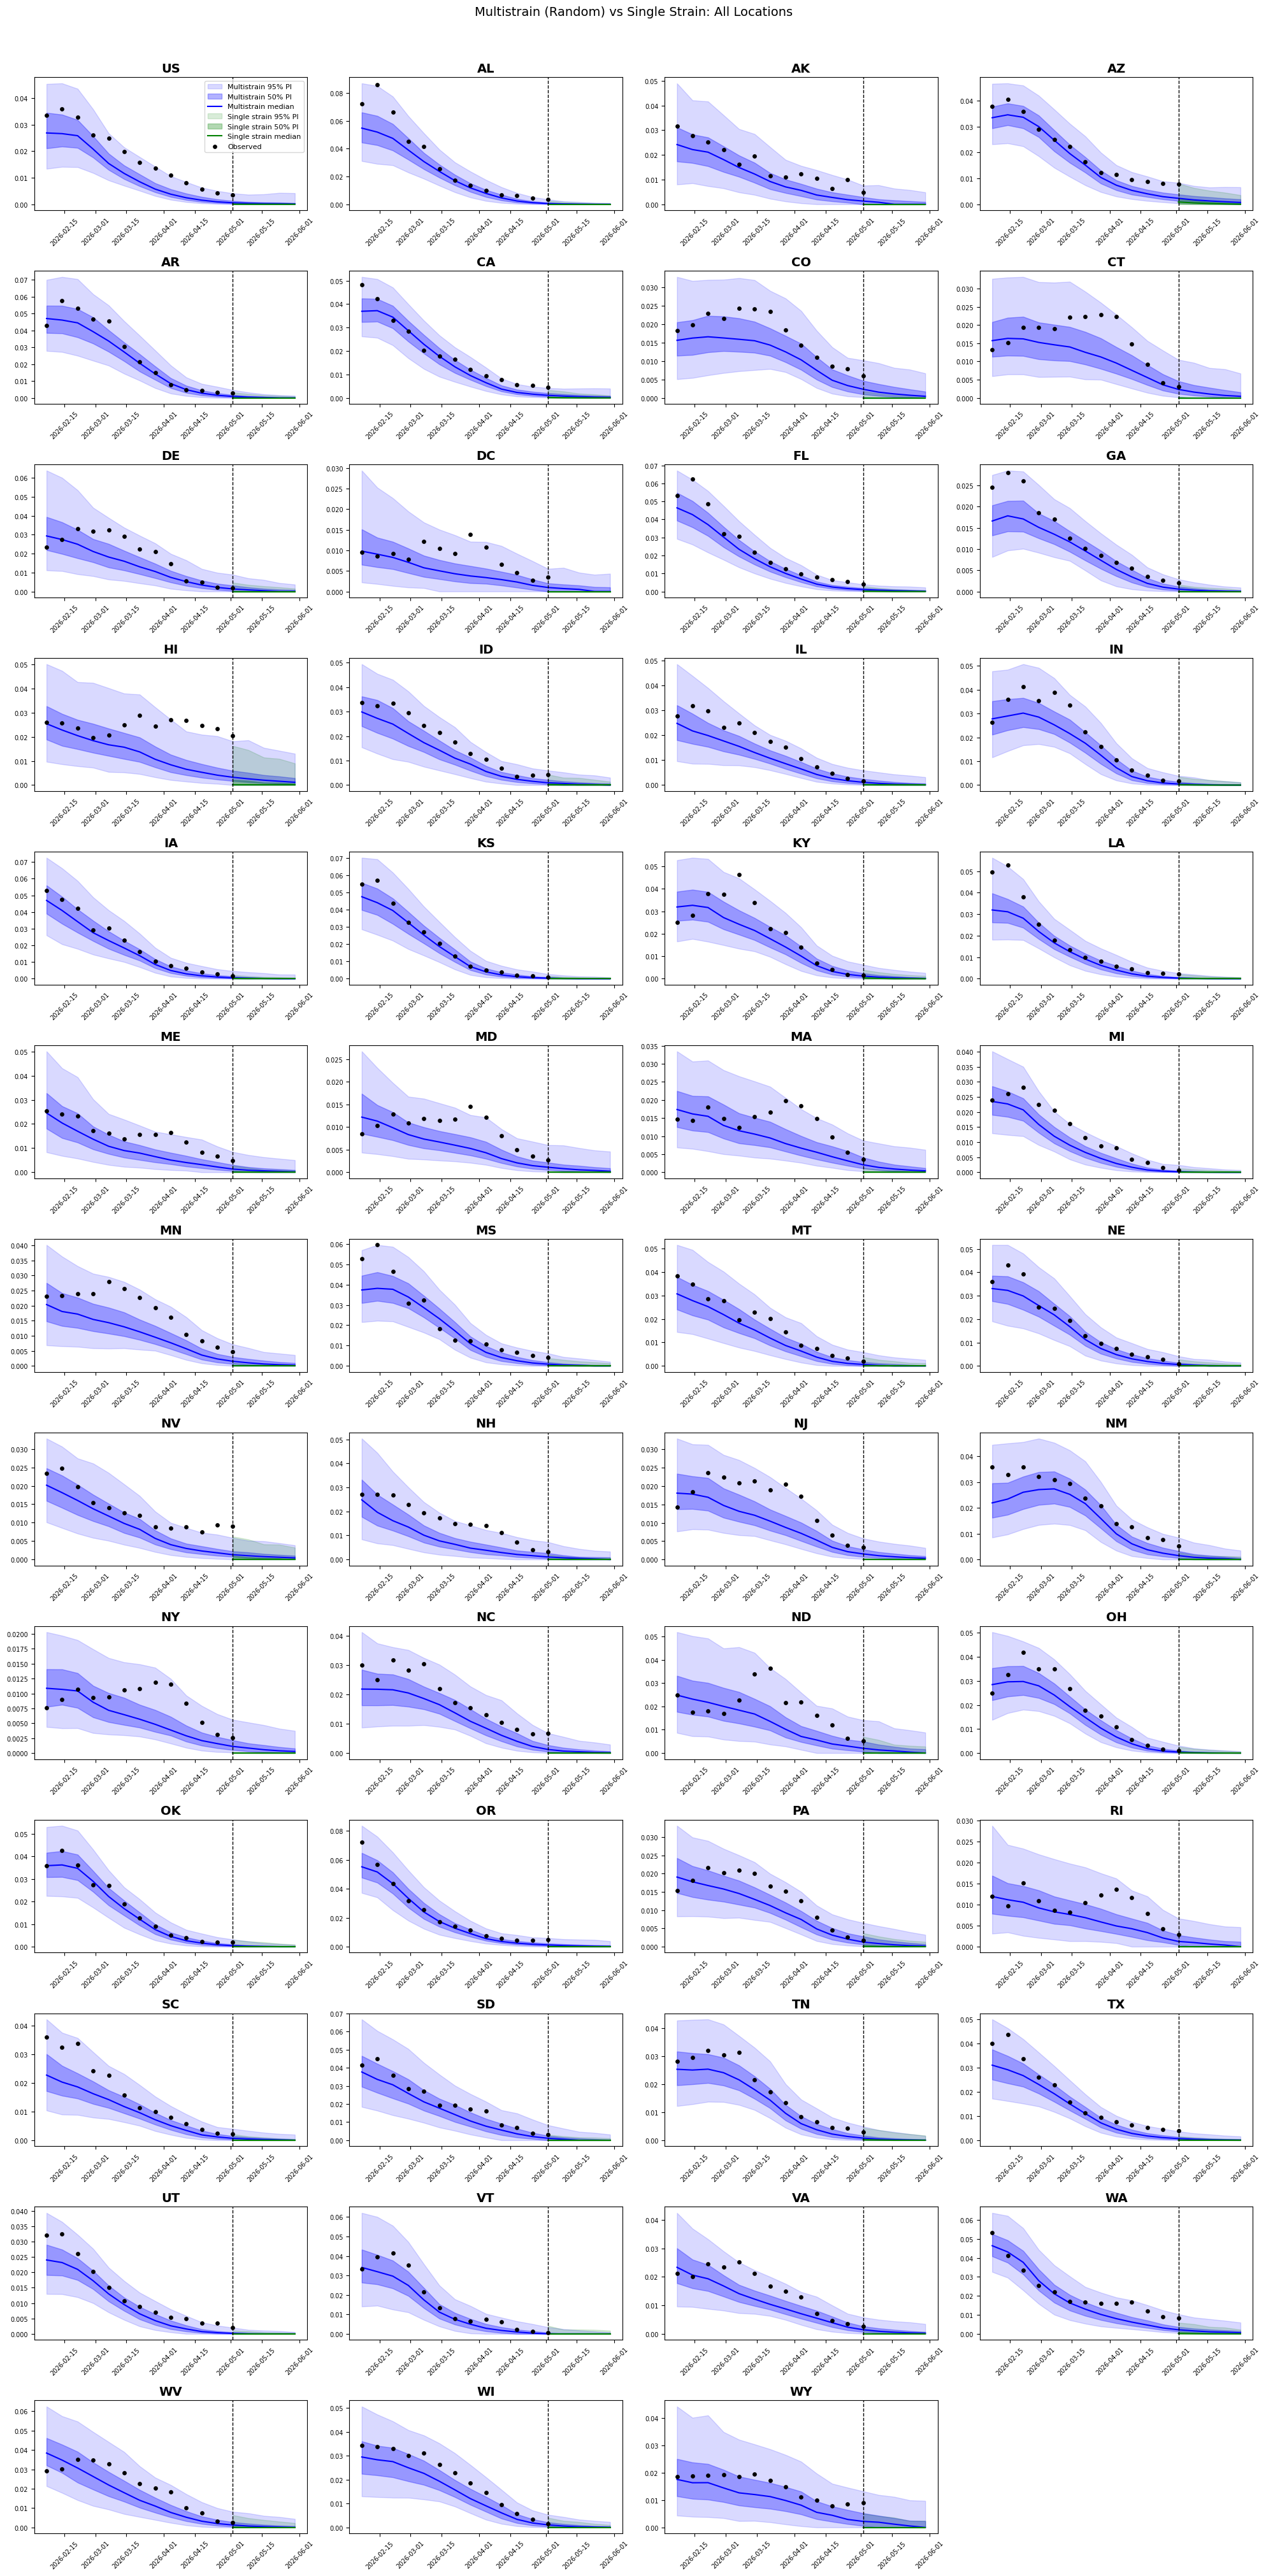

In [15]:
FILTER_PLOT = True
FILTER_PLOT_START = '2026-02-01'
LONG_PLOT_START = '2025-10-01'

if FILTER_PLOT:
    plot_start_date = pd.to_datetime(FILTER_PLOT_START)
    fname_prefix = 'filtered_'
else:
    plot_start_date = pd.to_datetime(LONG_PLOT_START)
    fname_prefix = ''

if BASELINE:
    plot_title = f'Baseline (NB k={BASELINE_k}) Multistrain (Random) vs Single Strain: All Locations'
    fname_prefix += 'baseline_'
else:
    plot_title = 'Multistrain (Random) vs Single Strain: All Locations'

plot_fname = f"{fname_prefix}{MULTISTRAIN_EXPERIMENT}_multistrain_vs_single_comparison.pdf'

# Filter data
random_quantiles_filter = random_quantiles[
    (random_quantiles['date'] >= plot_start_date) &
    (random_quantiles['date'] < final_date)
]
fit_surv_data_filter = fit_surv_data[
    (fit_surv_data['date'] >= plot_start_date) &
    (fit_surv_data['date'] < final_date)
]

# Convert df_single to wide format for plotting (matching random_quantiles format)
df_single_quantiles = df_single[df_single['output_type'] == 'quantile'].copy()
df_single_quantiles['target_end_date'] = pd.to_datetime(df_single_quantiles['target_end_date'])

# Pivot to get quantile columns
df_single_wide = df_single_quantiles.pivot_table(
    index=['location', 'target_end_date'],
    columns='output_type_id',
    values='value'
).reset_index()

# Rename columns to match random_quantiles format
df_single_wide.columns.name = None
df_single_wide = df_single_wide.rename(columns={
    'target_end_date': 'date',
    '0.025': 'q025', '0.25': 'q250', '0.5': 'q500', '0.75': 'q750', '0.975': 'q975'
})

# Filter to date range
df_single_filter = df_single_wide[
    (df_single_wide['date'] >= plot_start_date) & 
    (df_single_wide['date'] < final_date)
]

# Create 13x4 comparison figure: Random multistrain vs Single strain
fig, axes = plt.subplots(13, 4, figsize=(20, 40))
axes = axes.flatten()

for idx, pop in enumerate(populations):
    ax = axes[idx]
    abbrev = convert_location_name_format(value=pop, output_format="abbreviation", input_format="epydemix_population", location_type="iso")
    location_code = convert_location_name_format(value=abbrev, output_format="FIPS", input_format="abbreviation", location_type="iso")
        
    # Get data for this population
    rand_pop = random_quantiles_filter[random_quantiles_filter['location'] == pop].sort_values('date')
    single_pop = df_single_filter[df_single_filter['location'] == location_code].sort_values('date')
    fit_surv_data_pop = fit_surv_data_filter[fit_surv_data_filter['abbreviation'] == abbrev].sort_values('date')
    
    # Plot random multistrain sampling (blue)
    ax.fill_between(rand_pop['date'], rand_pop['q025'], rand_pop['q975'], 
                    alpha=0.15, color='blue', label='Multistrain 95% PI')
    ax.fill_between(rand_pop['date'], rand_pop['q250'], rand_pop['q750'], 
                    alpha=0.3, color='blue', label='Multistrain 50% PI')
    ax.plot(rand_pop['date'], rand_pop['q500'], 'b-', linewidth=1.5, label='Multistrain median')
    
    # Plot single strain (green)
    ax.fill_between(single_pop['date'], single_pop['q025'], single_pop['q975'], 
                    alpha=0.15, color='green', label='Single strain 95% PI')
    ax.fill_between(single_pop['date'], single_pop['q250'], single_pop['q750'], 
                    alpha=0.3, color='green', label='Single strain 50% PI')
    ax.plot(single_pop['date'], single_pop['q500'], 'g-', linewidth=1.5, label='Single strain median')
    
    # Plot ground truth (black markers)
    ax.scatter(fit_surv_data_pop['date'], fit_surv_data_pop['original_value'], 
               color='black', s=15, zorder=5, label='Observed')
    
    ax.set_title(abbrev, fontsize=14, fontweight='bold')
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.tick_params(axis='y', labelsize=7)
    ax.axvline(REFERENCE_DT - pd.Timedelta(weeks=1), color='black', linestyle='--', linewidth=1)
    
    # Only show legend for first subplot
    if idx == 0:
        ax.legend(fontsize=8, loc='upper right')

# Hide any unused subplots
for idx in range(len(populations), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle(plot_title, fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(f'{WORKING_DIR}/{plot_fname}', 
            dpi=150, bbox_inches='tight')
plt.show()

## Submission File

In [10]:
# Create complete FluSight submission
submission = create_ed_submission(
    trajectories_df=random_combined,
    reference_date=REFERENCE_DATE,
    horizons=get_flusight_horizons(),  # -1 is nowcast, 0-3 are forecasts
    value_col=VALUE_COL
)

print(f"Submission shape: {submission.shape}")
print(f"\nColumns: {submission.columns.tolist()}")
print(f"\nTargets: {submission['target'].unique()}")
print(f"Output types: {submission['output_type'].unique()}")
print(f"Horizons: {sorted(submission['horizon'].unique())}")
print(f"Locations: {submission['location'].nunique()}")
print(f"\nRows per target:")
print(submission.groupby(['target', 'output_type']).size())

Submission shape: (5865, 8)

Columns: ['reference_date', 'horizon', 'target_end_date', 'location', 'target', 'output_type', 'output_type_id', 'value']

Targets: <StringArray>
['wk inc flu prop ed visits']
Length: 1, dtype: str
Output types: <StringArray>
['quantile']
Length: 1, dtype: str
Horizons: [np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
Locations: 51

Rows per target:
target                     output_type
wk inc flu prop ed visits  quantile       5865
dtype: int64


In [11]:
submission

,reference_date,horizon,target_end_date,location,target,output_type,output_type_id,value
0,2026-05-09,-1,2026-05-02,01,wk inc flu prop ed visits,quantile,0.01,0.000
1,2026-05-09,-1,2026-05-02,01,wk inc flu prop ed visits,quantile,0.025,0.000
2,2026-05-09,-1,2026-05-02,01,wk inc flu prop ed visits,quantile,0.05,0.000
3,2026-05-09,-1,2026-05-02,01,wk inc flu prop ed visits,quantile,0.1,0.000
4,2026-05-09,-1,2026-05-02,01,wk inc flu prop ed visits,quantile,0.15,0.000
...,...,...,...,...,...,...,...,...
5860,2026-05-09,3,2026-05-30,US,wk inc flu prop ed visits,quantile,0.85,0.001
5861,2026-05-09,3,2026-05-30,US,wk inc flu prop ed visits,quantile,0.9,0.001
5862,2026-05-09,3,2026-05-30,US,wk inc flu prop ed visits,quantile,0.95,0.002
5863,2026-05-09,3,2026-05-30,US,wk inc flu prop ed visits,quantile,0.975,0.004


In [12]:
sub_prefix = "baseline_" if BASELINE else ""
submission.to_csv(f"{WORKING_DIR}/{sub_prefix}{REFERENCE_DATE}-MOBS-EpyStrain_Flu.csv",
                  index=False)